In [40]:
from matplotlib import testing
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = True
testing_mode = True

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
df_x = df_tv.iloc[:,1:-1]

df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)
continous_variables = df_dummy.select_dtypes(['float64']).columns
index = [df_dummy.columns.get_loc(col) for col in continous_variables]

x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

if testing_mode:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = \
        train_test_split(x, y, 
                        test_size=0.20,
                        stratify=y,
                        random_state=1)
else:
    X_train, y_train = x, y

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])

if testing_mode:
    X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]



In [39]:
X_train[0,:]

array([-0.78327632, -0.52586066,  1.16822652, -0.65596623,  0.35014098,
        0.48111583, -1.21669288, -0.89178372, -0.71319801, -1.41591056,
       -0.32211091,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ])

In [ ]:





# df_tv = pd.read_csv(training_data)
# counts = df_tv['Irrigation_Need'].value_counts()
# continous_variables = df_tv.select_dtypes(['float64']).columns

# #balanced data set
# df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
# df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
# df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# # Downsample majority class
# majority_downsampled = resample(df_tv_majority, 
#                               replace=False,  # Sample without replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # Oversample minority class
# minority_upsampled = resample(df_tv_minority, 
#                               replace=True,  # Sample with replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # # Oversample mid class
# # mid_upsampled = resample(df_tv_mid, 
# #                          replace=True,  # Sample with replacement
# #                          n_samples=len(df_tv_majority),  # Equalize class sizes
# #                          random_state=42)
# #df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
# df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
# df_tv = df_balanced if balanced else df_tv



# class_le = LabelEncoder()
# y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

# df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

# sc = StandardScaler().fit(df_dummy[continous_variables])
# df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
# x = df_dummy.to_numpy()

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = \
#     train_test_split(x, y, 
#                      test_size=0.20,
#                      stratify=y,
#                      random_state=1)




In [3]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
def plot_confusion_matrix(y_pred, y_test):

    labels = class_le.inverse_transform(np.unique(y_pred))
    confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                            class_le.inverse_transform(y_pred), 
                            sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [4]:
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)
mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                        n_estimators=2000, learning_rate=0.1, max_depth=5, reg_lambda=1, 
                        objective='multi:softmax', num_class=3, eval_metric='merror')
mxgb.fit(cupy.array(X_train), y_train)
mxgb.score(X_test, y_test)



/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [16:55:33] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


0.9851666666666666

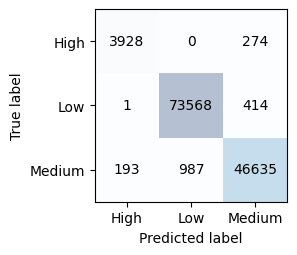

In [5]:
plot_confusion_matrix(mxgb.predict(X_test), y_test)

In [41]:
from lightgbm import LGBMClassifier
# device='cuda' is only supported in lightgbm built with: 
# pip install lightgbm --install-option=cmake.define.USE_CUDA=ON
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=5, reg_lambda=0.1,
                      boosting_type='gbdt')
lgbm.fit(X_train, y_train)
lgbm.score(X_test, y_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 573777, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9843730158730158

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


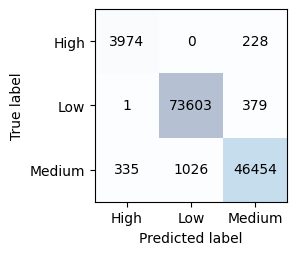

In [42]:
plot_confusion_matrix(lgbm.predict(X_test), y_test)

In [9]:
from catboost import CatBoostClassifier, Pool

test_data = catboost_pool = Pool(X_test,
                                 y_test)

weights = dict(zip(class_le.transform(class_le.classes_), [.2, .2, .6]))
params = {'iterations': 2000,
          'depth': 5,
          'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': True,
          'task_type': 'GPU',
          'reg_lambda': 10,
          'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)


from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)
                        
cb.fit(X_train, y_train)
cb.score(X_test, y_test)

0:	learn: 0.9636685	total: 938ms	remaining: 31m 14s
1:	learn: 0.8603903	total: 985ms	remaining: 16m 24s
2:	learn: 0.7754058	total: 1.03s	remaining: 11m 26s
3:	learn: 0.7050099	total: 1.08s	remaining: 8m 58s
4:	learn: 0.6474239	total: 1.12s	remaining: 7m 28s
5:	learn: 0.5934387	total: 1.17s	remaining: 6m 29s
6:	learn: 0.5485017	total: 1.22s	remaining: 5m 47s
7:	learn: 0.5092127	total: 1.26s	remaining: 5m 13s
8:	learn: 0.4736468	total: 1.29s	remaining: 4m 45s
9:	learn: 0.4429999	total: 1.32s	remaining: 4m 22s
10:	learn: 0.4157923	total: 1.35s	remaining: 4m 4s
11:	learn: 0.3908974	total: 1.38s	remaining: 3m 48s
12:	learn: 0.3692612	total: 1.41s	remaining: 3m 36s
13:	learn: 0.3497019	total: 1.44s	remaining: 3m 24s
14:	learn: 0.3316354	total: 1.48s	remaining: 3m 15s
15:	learn: 0.3130585	total: 1.5s	remaining: 3m 6s
16:	learn: 0.2989431	total: 1.53s	remaining: 2m 58s
17:	learn: 0.2855482	total: 1.55s	remaining: 2m 51s
18:	learn: 0.2720396	total: 1.58s	remaining: 2m 44s
19:	learn: 0.2611185	t

np.float64(0.9815238095238096)

In [7]:
dict(zip(class_le.classes_, [.2, .2, .6]))

{'High': 0.2, 'Low': 0.2, 'Medium': 0.6}

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


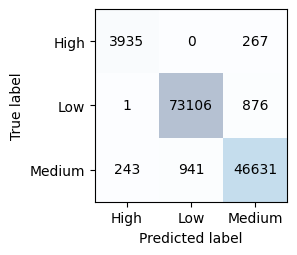

In [10]:
plot_confusion_matrix(cb.predict(X_test), y_test)

In [9]:
# from sklearn.ensemble import VotingClassifier

# voting_clf = VotingClassifier(estimators=[('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)], voting='soft')
# voting_clf.fit(X_train, y_train)
# voting_clf.score(X_test, y_test)



In [10]:
#plot_confusion_matrix(voting_clf.predict(X_test), y_test)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

base_models = [('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)]
#meta_model = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
meta_model = DecisionTreeClassifier(max_depth=5, random_state=1)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_test, y_test)
#stacking_clf.fit(x, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2738
[LightGBM] [Info] Number of data points in the train set: 573777, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2737
[LightGBM] [Info] Number of data points in the train set: 286889, number of used features: 43
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0:	learn: 0.9644902	total: 26.2ms	remaining: 52.4s
1:	learn: 0.8628482	total: 38ms	remaining: 38s
2:	learn: 0.7773690	total: 49ms	remaining: 32.6s
3:	learn: 0.7067309	total: 62.4ms	remaining: 31.1s
4:	learn: 0.6488558	total: 81.3ms	remaining: 32.4s
5:	learn: 0.5947491	total: 101ms	remaining: 33.5s
6:	learn: 0.5504232	total: 117ms	remaining: 33.4s
7:	learn: 0.5102426	total: 139ms	remaining: 34.6s
8:	learn: 0.4751091	total: 167ms	remaining: 37s
9:	learn: 0.4443222	total: 180ms	remaining: 35.9s
10:	learn: 0.4170608	total: 195ms	remaining: 35.2s
11:	learn: 0.3921049	total: 213ms	remaining: 35.3s
12:	learn: 0.3705020	total: 226ms	remaining: 34.6s
13:	learn: 0.3507061	total: 244ms	remaining: 34.6s
14:	learn: 0.3301702	total: 262ms	remaining: 34.6s
15:	learn: 0.3143140	total: 276ms	remaining: 34.3s
16:	learn: 0.2997463	total: 293ms	remaining: 34.2s
17:	learn: 0.2868692	total: 310ms	remaining: 34.1s
18:	learn: 0.2726243	total: 324ms	remaining: 33.8s
19:	learn: 0.2617123	total: 339ms	remaining:

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9853333333333333

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


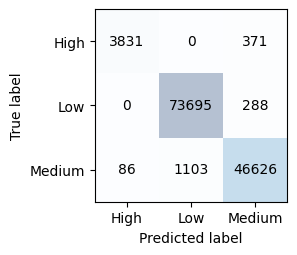

In [46]:
plot_confusion_matrix(stacking_clf.predict(X_test), y_test)

In [48]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values

df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], drop_first=False, dtype=int)
df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()
#df_test_dummy.head()
df_test_dummy[continous_variables].values

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


array([[-0.13255708, -0.67785809, -0.90990535, ..., -1.29681463,
         1.44098071, -0.43308981],
       [-0.66397779, -1.67347179,  0.70338123, ...,  0.9673366 ,
        -0.33005479, -0.17170529],
       [-0.28439157, -0.65588256,  0.10181674, ..., -1.36185624,
        -1.04368489, -1.23564247],
       ...,
       [ 1.46170505, -1.6038826 ,  1.74244716, ..., -0.06981342,
        -1.09821476, -0.82618875],
       [ 0.69168729, -1.65515884,  1.086195  , ..., -1.56752836,
        -0.42726022, -1.70525844],
       [ 0.13857593, -0.75294116,  1.33228956, ..., -0.07860283,
        -0.83030712,  1.34023617]], shape=(270000, 11))

In [47]:

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_stack = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(stacking_clf.predict(x_test))})
df_submission_stack.to_csv(os.path.join(out_dir, 'submission-stack_v4.csv'), index=False)

/home/ryanmcgreevy/Python-venvs/ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
